In [3]:
import random
import pickle
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

In [4]:
# Configuration
RANDOM_SEED = 42

BATCH_SIZE = 64

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

NUM_EPOCHS = 50

PATIENCE = 10

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using Device : {DEVICE}")

Using Device : cpu


In [5]:
# Set Random Seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)
ARTIFACT_DIR = Path("artifacts")

In [6]:
X_train = np.load(ARTIFACT_DIR / "X_train.npy")
X_val = np.load(ARTIFACT_DIR / "X_val.npy")
X_test = np.load(ARTIFACT_DIR / "X_test.npy")

Y_train = np.load(ARTIFACT_DIR / "Y_train.npy")
Y_val = np.load(ARTIFACT_DIR / "Y_val.npy")
Y_test = np.load(ARTIFACT_DIR / "Y_test.npy")

with open(
    ARTIFACT_DIR / "bacteria_encoder.pkl",
    "rb"
) as file:

    bacteria_encoder = pickle.load(file)

with open(
    ARTIFACT_DIR / "clinical_scaler.pkl",
    "rb"
) as file:

    clinical_scaler = pickle.load(file)

In [7]:
with open(
    ARTIFACT_DIR / "infection_imputer.pkl",
    "rb"
) as file:

    infection_imputer = pickle.load(file)

with open(
    ARTIFACT_DIR / "feature_columns.json",
    "r"
) as file:

    feature_columns = json.load(file)

with open(
    ARTIFACT_DIR / "target_columns.json",
    "r"
) as file:

    target_columns = json.load(file)

print("=" * 60)

print("Training")

print(X_train.shape)

print(Y_train.shape)

print("=" * 60)

print("Validation")

print(X_val.shape)

print(Y_val.shape)

print("=" * 60)

print("Testing")

print(X_test.shape)

print(Y_test.shape)

print("Training NaNs :", np.isnan(X_train).sum())

print("Validation NaNs :", np.isnan(X_val).sum())

print("Testing NaNs :", np.isnan(X_test).sum())

print(np.unique(Y_train))

Training
(6962, 7)
(6962, 15)
Validation
(1492, 7)
(1492, 15)
Testing
(1493, 7)
(1493, 15)
Training NaNs : 0
Validation NaNs : 0
Testing NaNs : 0
[0. 1.]


In [8]:
# ============================================================
# Custom Dataset
# ============================================================

class ClinicalDataset(Dataset):

    def __init__(self, X, Y):

        self.clinical = torch.tensor(
            X[:, :6],
            dtype=torch.float32
        )

        self.bacteria = torch.tensor(
            X[:, 6],
            dtype=torch.long
        )

        self.targets = torch.tensor(
            Y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.targets)

    def __getitem__(self, index):

        return (
            self.clinical[index],
            self.bacteria[index],
            self.targets[index]
        )

In [9]:
train_dataset = ClinicalDataset(
    X_train,
    Y_train
)

val_dataset = ClinicalDataset(
    X_val,
    Y_val
)

test_dataset = ClinicalDataset(
    X_test,
    Y_test
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

clinical, bacteria, target = train_dataset[0]

print("Clinical Features")
print(clinical)

print("\nBacteria")
print(bacteria)

print("\nTargets")
print(target)

6962
1492
1493
Clinical Features
tensor([0.2206, 0.0000, 0.0000, 0.0000, 1.0000, 0.4752])

Bacteria
tensor(4)

Targets
tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [10]:
# ============================================================
# DataLoaders
# ============================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

clinical_batch, bacteria_batch, target_batch = next(iter(train_loader))

print("Clinical Batch Shape :", clinical_batch.shape)
print("Bacteria Batch Shape :", bacteria_batch.shape)
print("Target Batch Shape :", target_batch.shape)

Clinical Batch Shape : torch.Size([64, 6])
Bacteria Batch Shape : torch.Size([64])
Target Batch Shape : torch.Size([64, 15])


In [11]:
# ============================================================
# Sentinel Multi-Target MLP
# ============================================================
class SentinelMultiTargetMLP(nn.Module):
    def __init__(self):
        super().__init__()

        # ----------------------------------------------------
        # Bacteria Embedding
        # ----------------------------------------------------
        self.embedding = nn.Embedding(
            num_embeddings=len(bacteria_encoder.classes_),
            embedding_dim=4
        )

        # ----------------------------------------------------
        # Clinical Branch
        # ----------------------------------------------------
        self.clinical_layer = nn.Sequential(
            nn.Linear(6, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------
        self.classifier = nn.Sequential(
            nn.Linear(68, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 15)
        )

    def forward(self, clinical, bacteria):
        clinical_features = self.clinical_layer(clinical)
        bacteria_embedding = self.embedding(bacteria)
        combined = torch.cat(
            [clinical_features, bacteria_embedding],
            dim=1
        )
        logits = self.classifier(combined)
        return logits

In [12]:
model = SentinelMultiTargetMLP().to(DEVICE)

print(model)

clinical_batch, bacteria_batch, target_batch = next(iter(train_loader))
clinical_batch = clinical_batch.to(DEVICE)
bacteria_batch = bacteria_batch.to(DEVICE)
output = model(
    clinical_batch,
    bacteria_batch)
print(output.shape)

print(output[:2])

SentinelMultiTargetMLP(
  (embedding): Embedding(9, 4)
  (clinical_layer): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=68, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=15, bias=True)
  )
)
torch.Size([64, 15])
tensor([[ 0.0834, -0.2273,  0.1518, -0.4320, -0.4577,  0.0322, -0.4147,  0.7692,
          0.3141, -0.4448, -0.3491, -0.7022, -0.0801, -0.5910,  0.2258],
        [ 0.2618, -0.0929,  0.28

In [13]:
# ============================================================
# Compute Positive Class Weights
# ============================================================
pos_weights = []
for column in range(Y_train.shape[1]):
    labels = Y_train[:, column]
    # Ignore missing labels
    valid_labels = labels[~np.isnan(labels)]
    positive_count = np.sum(valid_labels == 1)
    negative_count = np.sum(valid_labels == 0)
    weight = negative_count / (positive_count + 1e-8)
    pos_weights.append(weight)
pos_weight_tensor = torch.tensor(
    pos_weights,
    dtype=torch.float32,
    device=DEVICE)
print("Positive Class Weights")
print(pos_weight_tensor)

print(pos_weight_tensor.shape)

Positive Class Weights
tensor([0.6752, 0.6671, 0.6972, 0.6784, 0.6882, 0.6886, 3.6945, 3.7652, 5.2272,
        5.5928, 5.1017, 5.3062, 5.4048, 5.4403, 5.3638])
torch.Size([15])


In [14]:
# ============================================================
# Masked BCEWithLogitsLoss
# ============================================================
class MaskedBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight):
        super().__init__()
        self.loss_fn = nn.BCEWithLogitsLoss(
            reduction="none",
            pos_weight=pos_weight
        )

    def forward(self, logits, targets):
        # Mask valid targets
        mask = ~torch.isnan(targets)

        # Replace NaNs with zeros
        # (They will be ignored by the mask)
        targets = torch.where(
            mask,
            targets,
            torch.zeros_like(targets)
        )

        # Compute element-wise loss
        loss = self.loss_fn(logits, targets)

        # Keep only valid losses
        loss = loss * mask.float()

        # Average over valid labels only
        return loss.sum() / mask.sum()


criterion = MaskedBCEWithLogitsLoss(
    pos_weight=pos_weight_tensor)

clinical_batch, bacteria_batch, target_batch = next(iter(train_loader))
clinical_batch = clinical_batch.to(DEVICE)
bacteria_batch = bacteria_batch.to(DEVICE)
target_batch = target_batch.to(DEVICE)
logits = model(
    clinical_batch,
    bacteria_batch)
loss = criterion(
    logits,
    target_batch)
print(loss)

tensor(0.9996, grad_fn=<DivBackward0>)


In [15]:
# ============================================================
# Optimizer
# ============================================================
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)

# ============================================================
# Learning Rate Scheduler
# ============================================================
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3)

In [16]:
# ============================================================
# Train One Epoch
# ============================================================
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for clinical, bacteria, targets in dataloader:
        clinical = clinical.to(device)
        bacteria = bacteria.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(clinical, bacteria)
        loss = criterion(logits, targets)
        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(dataloader)

# ============================================================
# Validate One Epoch
# ============================================================
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for clinical, bacteria, targets in dataloader:
            clinical = clinical.to(device)
            bacteria = bacteria.to(device)
            targets = targets.to(device)
            logits = model(clinical, bacteria)
            loss = criterion(logits, targets)
            running_loss += loss.item()
    return running_loss / len(dataloader)

In [17]:
# ============================================================
# Training Loop
# ============================================================
train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs_without_improvement = 0
for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )
    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| LR: {current_lr:.6f}"
    )

    # ----------------------------
    # Save Best Model
    # ----------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            model.state_dict(),
            "best_model.pth"
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # ----------------------------
    # Early Stopping
    # ----------------------------
    if epochs_without_improvement >= PATIENCE:
        print("\nEarly stopping triggered.")
        break

Epoch [01/50] | Train Loss: 0.9153 | Val Loss: 0.8698 | LR: 0.001000
Epoch [02/50] | Train Loss: 0.8954 | Val Loss: 0.8682 | LR: 0.001000
Epoch [03/50] | Train Loss: 0.8891 | Val Loss: 0.8660 | LR: 0.001000
Epoch [04/50] | Train Loss: 0.8876 | Val Loss: 0.8665 | LR: 0.001000
Epoch [05/50] | Train Loss: 0.8865 | Val Loss: 0.8656 | LR: 0.001000
Epoch [06/50] | Train Loss: 0.8843 | Val Loss: 0.8648 | LR: 0.001000
Epoch [07/50] | Train Loss: 0.8829 | Val Loss: 0.8656 | LR: 0.001000
Epoch [08/50] | Train Loss: 0.8831 | Val Loss: 0.8655 | LR: 0.001000
Epoch [09/50] | Train Loss: 0.8814 | Val Loss: 0.8638 | LR: 0.001000
Epoch [10/50] | Train Loss: 0.8815 | Val Loss: 0.8635 | LR: 0.001000
Epoch [11/50] | Train Loss: 0.8810 | Val Loss: 0.8643 | LR: 0.001000
Epoch [12/50] | Train Loss: 0.8797 | Val Loss: 0.8638 | LR: 0.001000
Epoch [13/50] | Train Loss: 0.8804 | Val Loss: 0.8641 | LR: 0.001000
Epoch [14/50] | Train Loss: 0.8794 | Val Loss: 0.8637 | LR: 0.000500
Epoch [15/50] | Train Loss: 0.8777

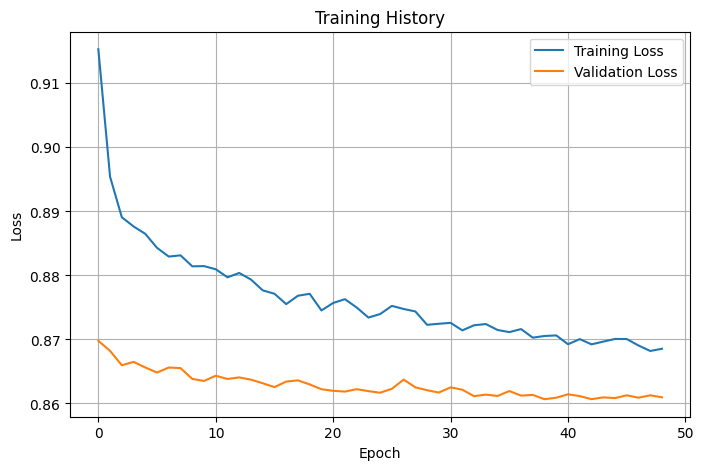

In [21]:
# ============================================================
# Load Best Model
# ============================================================

model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=DEVICE
    )
)

# ============================================================
# Training History
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training History")

plt.legend()

plt.grid(True)

plt.show()